In [118]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
X,Y = make_moons(n_samples=500,noise = 0.30,random_state=42)
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=42)

In [119]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr',LogisticRegression(random_state=42)),
        ('rf',RandomForestClassifier(random_state=42)),
        ('svc',SVC(random_state=42))
    ]
)

voting_clf.fit(X_train,Y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

In [120]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(),n_estimators=500,n_jobs=-1,random_state=42,oob_score=True)
bag_clf.fit(X_train,Y_train)

dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train,Y_train)

DecisionTreeClassifier(random_state=42)

Great follow-up! Let’s break it down **visually** so you can **see** where the grid is and how it's created by `np.meshgrid()`.

---

## 👨‍🏫 Starting Point:

```python
import numpy as np

x = np.array([1, 2, 3])
y = np.array([10, 20])

X, Y = np.meshgrid(x, y)
```

### ✨ What we gave:

* `x = [1, 2, 3]` → x-axis values
* `y = [10, 20]` → y-axis values

---

## 🔲 What `meshgrid` does:

It creates all possible **(x, y)** coordinate pairs in a **grid** structure.

### 1️⃣ Coordinate Pairs Created:

```
(x=1, y=10)   (x=2, y=10)   (x=3, y=10)
(x=1, y=20)   (x=2, y=20)   (x=3, y=20)
```

Each of these is a **point on a 2D grid**.

---

### 2️⃣ X and Y Arrays Returned:

```python
X =
[[1 2 3]
 [1 2 3]]

Y =
[[10 10 10]
 [20 20 20]]
```

* `X[i][j]` contains the x-coordinate of the point at row `i`, column `j`
* `Y[i][j]` contains the y-coordinate of the same point

So for example:

* `X[1][2] = 3`, `Y[1][2] = 20` → This point is (3, 20)

---

## 🎨 Visual Grid (Conceptual):

Here’s a **2D grid visualization** of `(X[i][j], Y[i][j])`:

|        | x=1    | x=2    | x=3    |
| ------ | ------ | ------ | ------ |
| y=10 → | (1,10) | (2,10) | (3,10) |
| y=20 → | (1,20) | (2,20) | (3,20) |

That’s your meshgrid — every combination of `x` and `y` values arranged like a 2D grid.

---

## 📌 Why is this useful?

You can now evaluate any function at every point on the grid. For example:

```python
Z = X + Y
```

Would produce:

```
[[11 12 13]
 [21 22 23]]
```

Because:

* `Z[0][0] = 1 + 10 = 11`
* `Z[1][2] = 3 + 20 = 23`

---

## ✅ Summary

* `np.meshgrid()` does **not** create a visual grid on its own.
* It returns **2 arrays** (X and Y), which **together define the grid** of coordinates.
* You use these arrays to evaluate functions, plot surfaces, or draw decision boundaries.

---

Want to see it drawn with `matplotlib`?


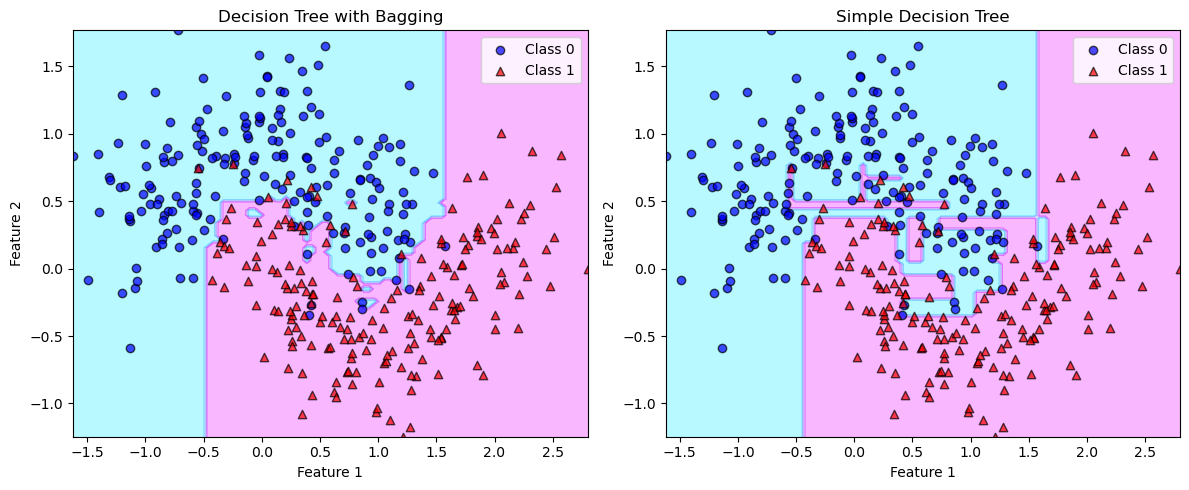

In [121]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X_train, Y_train, feature_names=("Feature 1", "Feature 2"), title="Decision Boundary",self_plot = True):
    # Create meshgrid
    x_min, x_max = X_train[:, 0].min(), X_train[:, 0].max()
    y_min, y_max = X_train[:, 1].min(), X_train[:, 1].max()
    X1 = np.linspace(x_min, x_max, num=100)
    X2 = np.linspace(y_min, y_max, num=100)
    X_grid, Y_grid = np.meshgrid(X1, X2)
    grid = np.c_[X_grid.ravel(), Y_grid.ravel()]
    
    # Predict on mesh
    Z = model.predict(grid).reshape(X_grid.shape)
    
    # Plot decision surface
    plt.contourf(X_grid, Y_grid, Z, alpha=0.3, cmap='cool')
    
    # Class separation
    class_0 = Y_train == 0
    class_1 = Y_train == 1
    
    # Plot data points
    plt.scatter(X_train[class_0, 0], X_train[class_0, 1],
                color='blue', edgecolor='k', marker='o', label='Class 0', alpha=0.7)
    plt.scatter(X_train[class_1, 0], X_train[class_1, 1],
                color='red', edgecolor='k', marker='^', label='Class 1', alpha=0.7)
    
    # Labels and legend
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.legend()
    if self_plot:
        plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.sca(axes[0]) 
plot_decision_boundary(bag_clf, X_train, Y_train, title="Decision Tree with Bagging",self_plot=False)
plt.sca(axes[1]) 
plot_decision_boundary(dec_tree, X_train, Y_train, title="Simple Decision Tree",self_plot=False)
plt.tight_layout()
plt.show()

In [122]:
bag_clf.oob_score_

0.896

In [124]:
y_pred = bag_clf.predict(X_test)

In [126]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.92

In [130]:
bag_clf.oob_decision_function_[:3]

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=500,max_leaf_nodes = 16,n_jobs= -1, random_state=42)
rnd_clf.fit(X_train,Y_train)
y_pred_rf = rnd_clf.predict(X_test)

In [133]:
rnd_clf.feature_importances_

array([0.42253629, 0.57746371])

In [134]:
from sklearn.ensemble import AdaBoostClassifier

abc_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),n_estimators=50,learning_rate= 0.5,random_state=42)
abc_clf.fit(X_train,Y_train)

c:\Users\jitik\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, random_state=42)

In [135]:
abc_clf.score(X_test,Y_test)

0.888